In [1]:
import json
import pandas as pd
from IPython.display import Image, JSON, display
from run_main import run
from helper_funcs import get_worm_json, write_worm_json

In [2]:
origFolderName="notebooks/example_W2D18L"
outputFolderName=origFolderName + "_evo"

Further optimizations can also be performed with the "W2DSR" model. The parameters used are those supplied in the command line arguments, or if not, in the 'Evolutionary Optimization Parameters' of the JSON file (if there is no JSON file defaults are used):

In [3]:
json_data = get_worm_json(origFolderName)
print('Evolutionary Optimization Parameters: ' + json.dumps(json_data['Evolutionary Optimization Parameters'], indent=2))

Evolutionary Optimization Parameters: {
  "CheckpointInterval": {
    "value": 5
  },
  "CrossoverMode": {
    "value": 0
  },
  "CrossoverProbability": {
    "value": 0.5
  },
  "Duration": {
    "value": 50.0
  },
  "ElitistFraction": {
    "value": 0.04
  },
  "MaxExpectedOffspring": {
    "value": 1.1
  },
  "MaxGenerations": {
    "value": 180
  },
  "MutationVariance": {
    "value": 0.1
  },
  "N_curvs": {
    "value": 23
  },
  "PopulationSize": {
    "value": 66
  },
  "ReEvaluationFlag": {
    "value": 1
  },
  "ReproductionMode": {
    "value": 1
  },
  "SearchConstraint": {
    "value": 1
  },
  "SelectionMode": {
    "value": 1
  },
  "StepSize": {
    "value": 0.01
  },
  "Transient": {
    "value": 10.0
  },
  "VectSize": {
    "value": 30
  },
  "VectSize_temo": {
    "value": -1
  },
  "agarfreq": {
    "value": 0.44
  },
  "avg_speed": {
    "value": 0.00022
  },
  "evo_type": {
    "value": "Evo18"
  },
  "fileprefix": {
    "value": ""
  },
  "osc_tbase": {
    "val

In [4]:
args = dict(
    modelFolder="Worm2D", #folder containing the compiled C++ binary code
    modelName="W2DSR",#rerun using the generic json loaded model
    outputFolderName=outputFolderName, #output folder
    inputFolderName=origFolderName, #input folder
    overwrite=True, #allow overwrite of output folder 
    randInitState=False, #use fixed initial conditions from JSON file
    doTestRun=True, #run a single simple simulation
)

Directory 'notebooks/example_W2D18L_evo' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '10', '--max_generations', '5', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo', '--modelname', 'W2DSR']
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_evo/search.cpt with size 30
setting  population size to cpt population size: 66
Resuming search
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json

Loading activity data from: notebooks/example_W2D18L_evo/act.dat
Loading curvature data from: notebooks/example_W2D18L_evo/curv.dat
Loading body position data from: notebooks/example_W2D18L_evo/body.dat
Saved plot image to: notebooks/example_W2D18L_evo/ExampleActivity.png
Saved plot

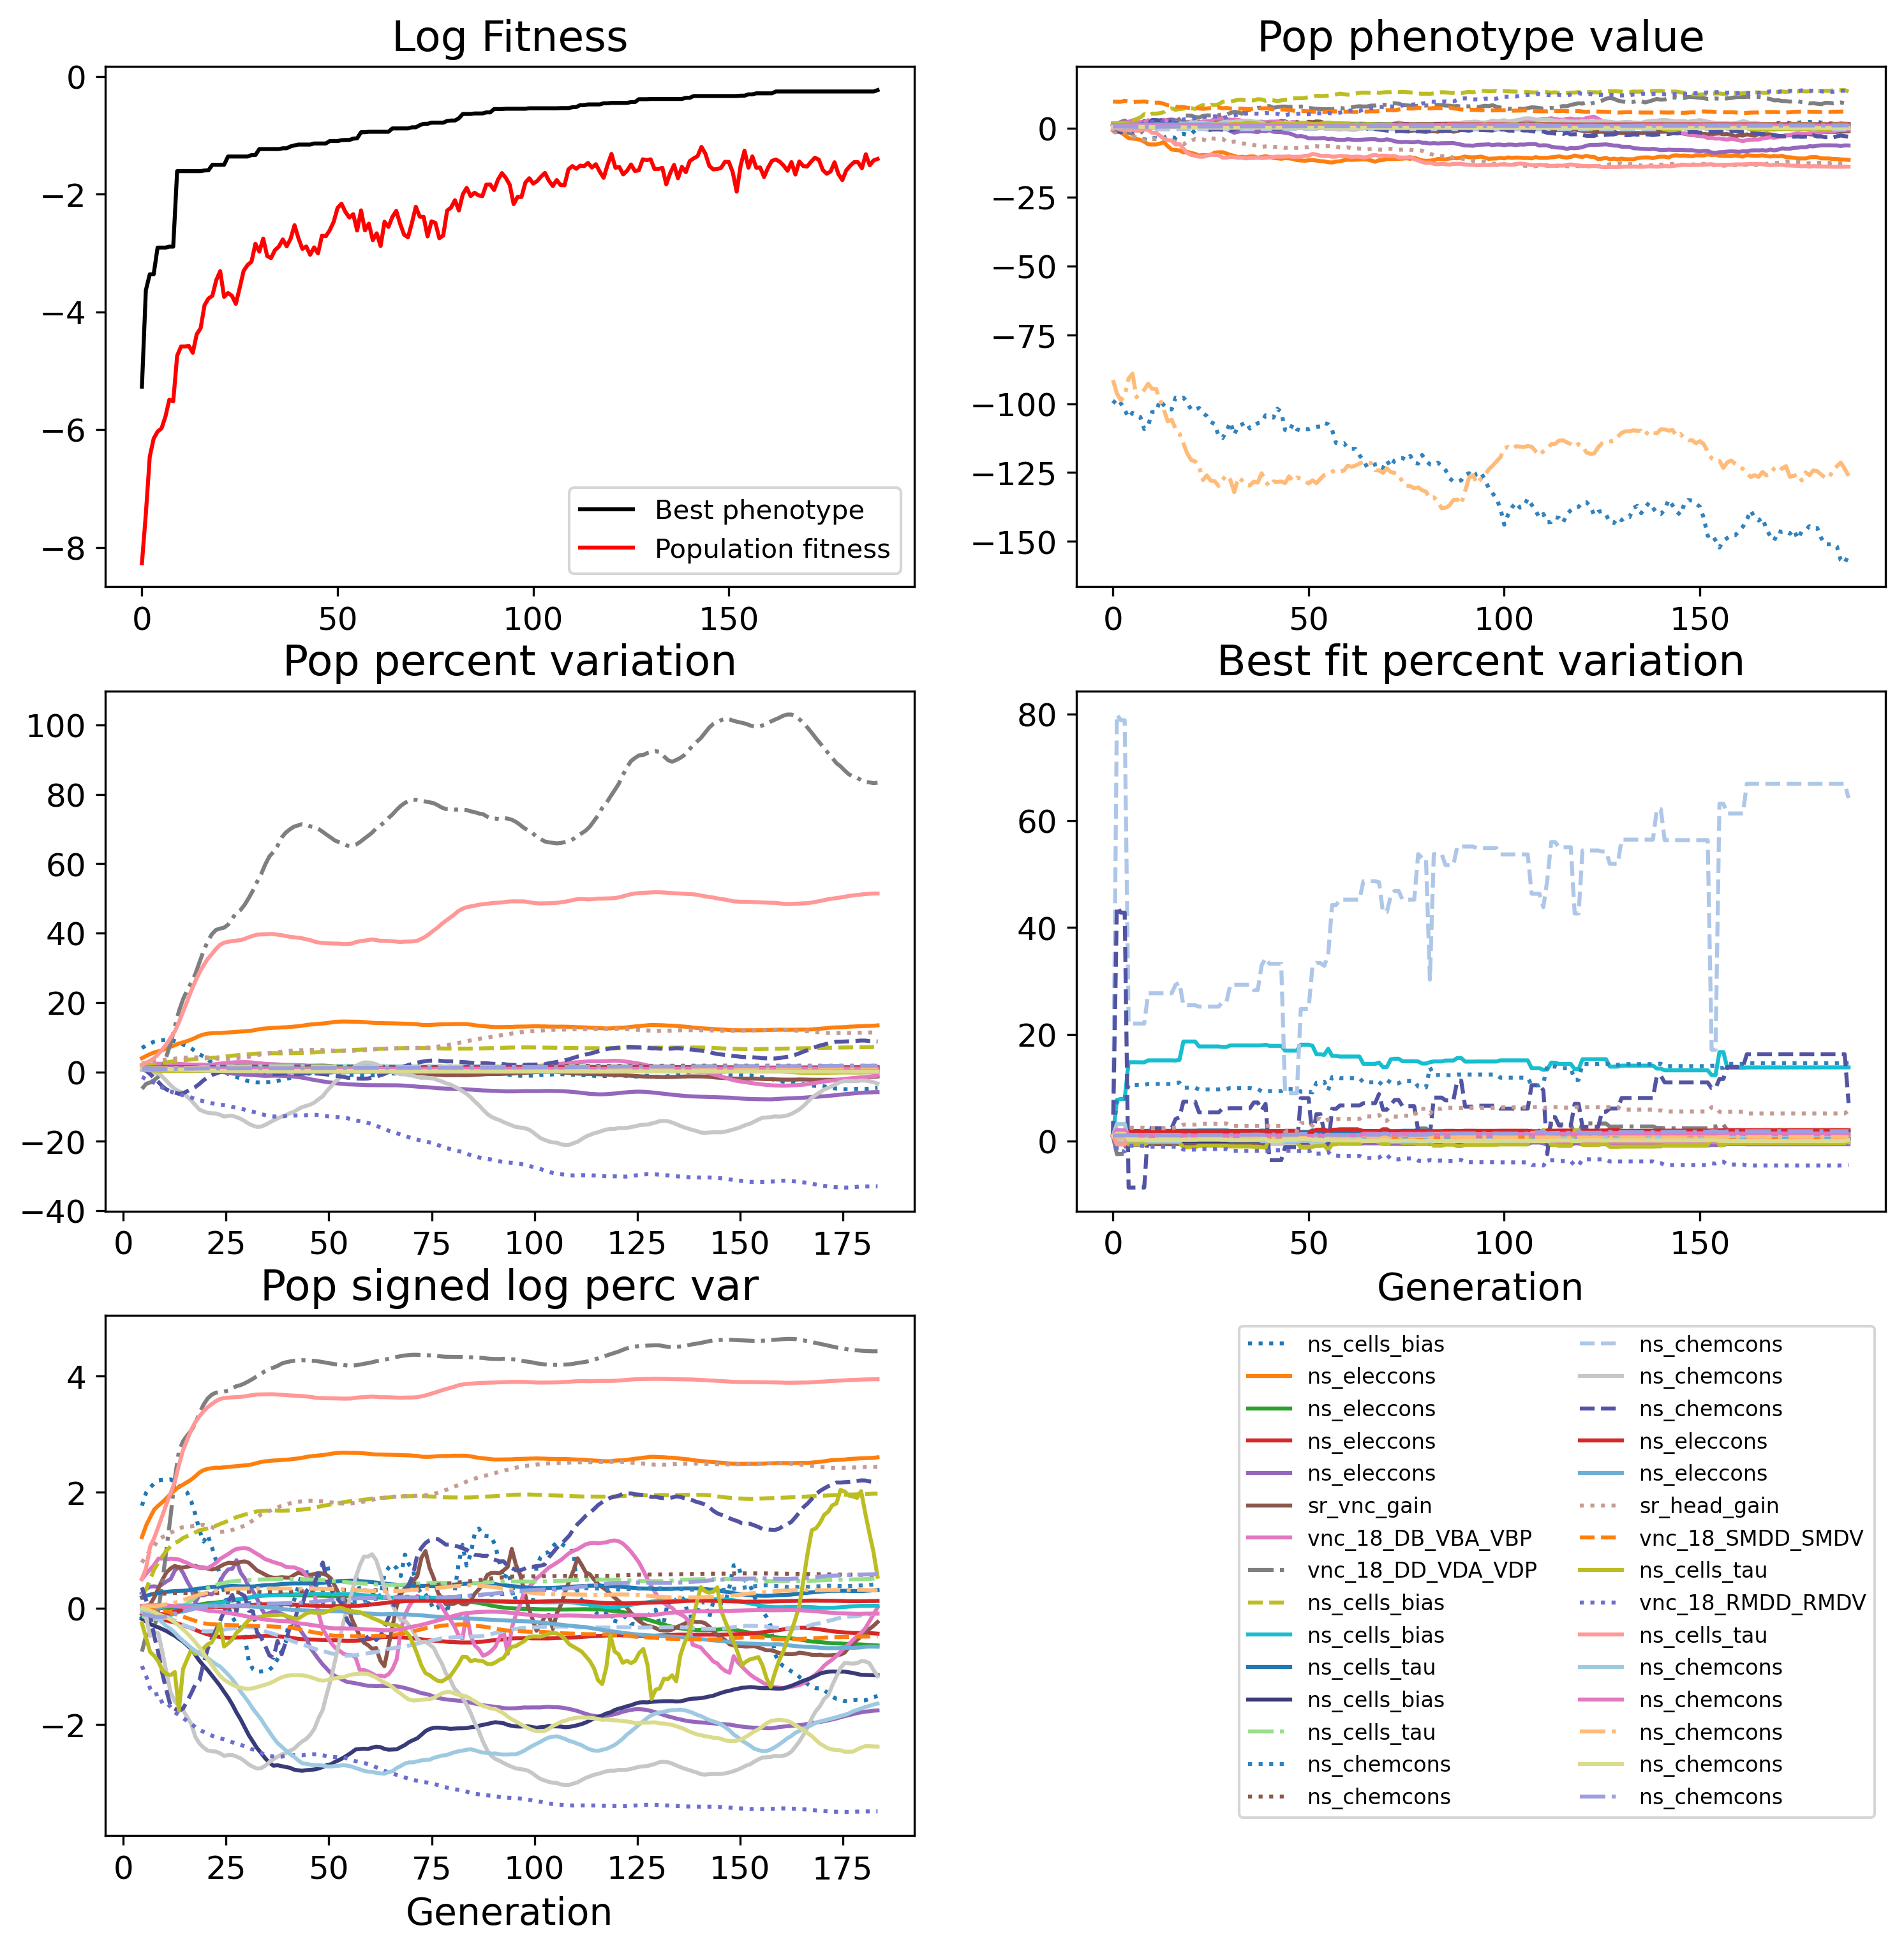

In [5]:
args['doEvol']=True #perform the optimization before running the simulation
args['evoAvLen']=10 #plot moving average of evolution history figures  
args['maxGens']=5 #run the optimization for ten more generations 
args['popSize']=10 #population size for optimization
run(**args)
new_json_data = get_worm_json(outputFolderName)
Image(filename=outputFolderName + '/EvoHist.png')

In [6]:
with open(outputFolderName + '/fitness.dat') as f:
    lines = f.readlines()
print(''.join(lines[-20:]))

169.0 0.7721968913 0.2179049288 0.08564123014
170.0 0.7721968913 0.2158700255 0.09434296223
171.0 0.7721968913 0.2342835284 0.09125587358
172.0 0.7721968913 0.2510128811 0.09799942922
173.0 0.7721968913 0.2423529054 0.1029283492
174.0 0.7721968913 0.2037848281 0.09616105234
175.0 0.7721968913 0.1910316735 0.09025206049
176.0 0.7721968913 0.1983732874 0.08925659604
177.0 0.7721968913 0.2322568728 0.09706176101
178.0 0.7721968913 0.1899098001 0.08192311125
179.0 0.7721968913 0.1714120528 0.08265401252
180.0 0.7721968913 0.2025202607 0.08576220081
181.0 0.7721968913 0.2186193757 0.08507806098
182.0 0.7721968913 0.2325960988 0.09321619325
183 0.7721968913 0.2325960988 0.09321619325
184 0.7721968973 0.209871112 0.08023946681
185 0.7721968973 0.2661167143 0.09742796245
186 0.7721968973 0.2203478686 0.09655478645
187 0.7721968973 0.2397428535 0.1009723406
188 0.7903654022 0.2457370292 0.1033548627



In the above evolution although the "popSize" parameter was set to 10 this was ignored by the actual execution because a checkpoint 'CPT' file was found in the directory (which had been copied from the input folder). In this case all the evolution parameters, except for the maximum number of generations, are set from this CPT file.

In [7]:
print(json.dumps(new_json_data['Evolutionary Optimization Parameters']['PopulationSize'], indent=2))

{
  "value": 66
}


To force the model to use the reduced "popSize" we need to set the "doCPT" parameter to false. In this case the entire worm population is initialized from the best fit worm parameter values which are stored in the JSON file. We also want to continue the evolution in the new output folder so we make sure to unset the 'inputFolderName' parameter:

Directory 'notebooks/example_W2D18L_evo' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '20', '--max_generations', '5', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo', '--modelname', 'W2DSR', '-docpt', '0']
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
construct from best gene notebooks/example_W2D18L_evo/best.gen.dat with gene size 30
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json

Loading activity data from: notebooks/example_W2D18L_evo/act.dat
Loading curvature data from: notebooks/example_W2D18L_evo/curv.dat
Loading body position data from: notebooks/example_W2D18L_evo/body.dat
Saved plot image to: notebooks/example_W2D18L_evo/ExampleActivity.png
Saved plot image to: notebooks/example_W2D18L_evo/

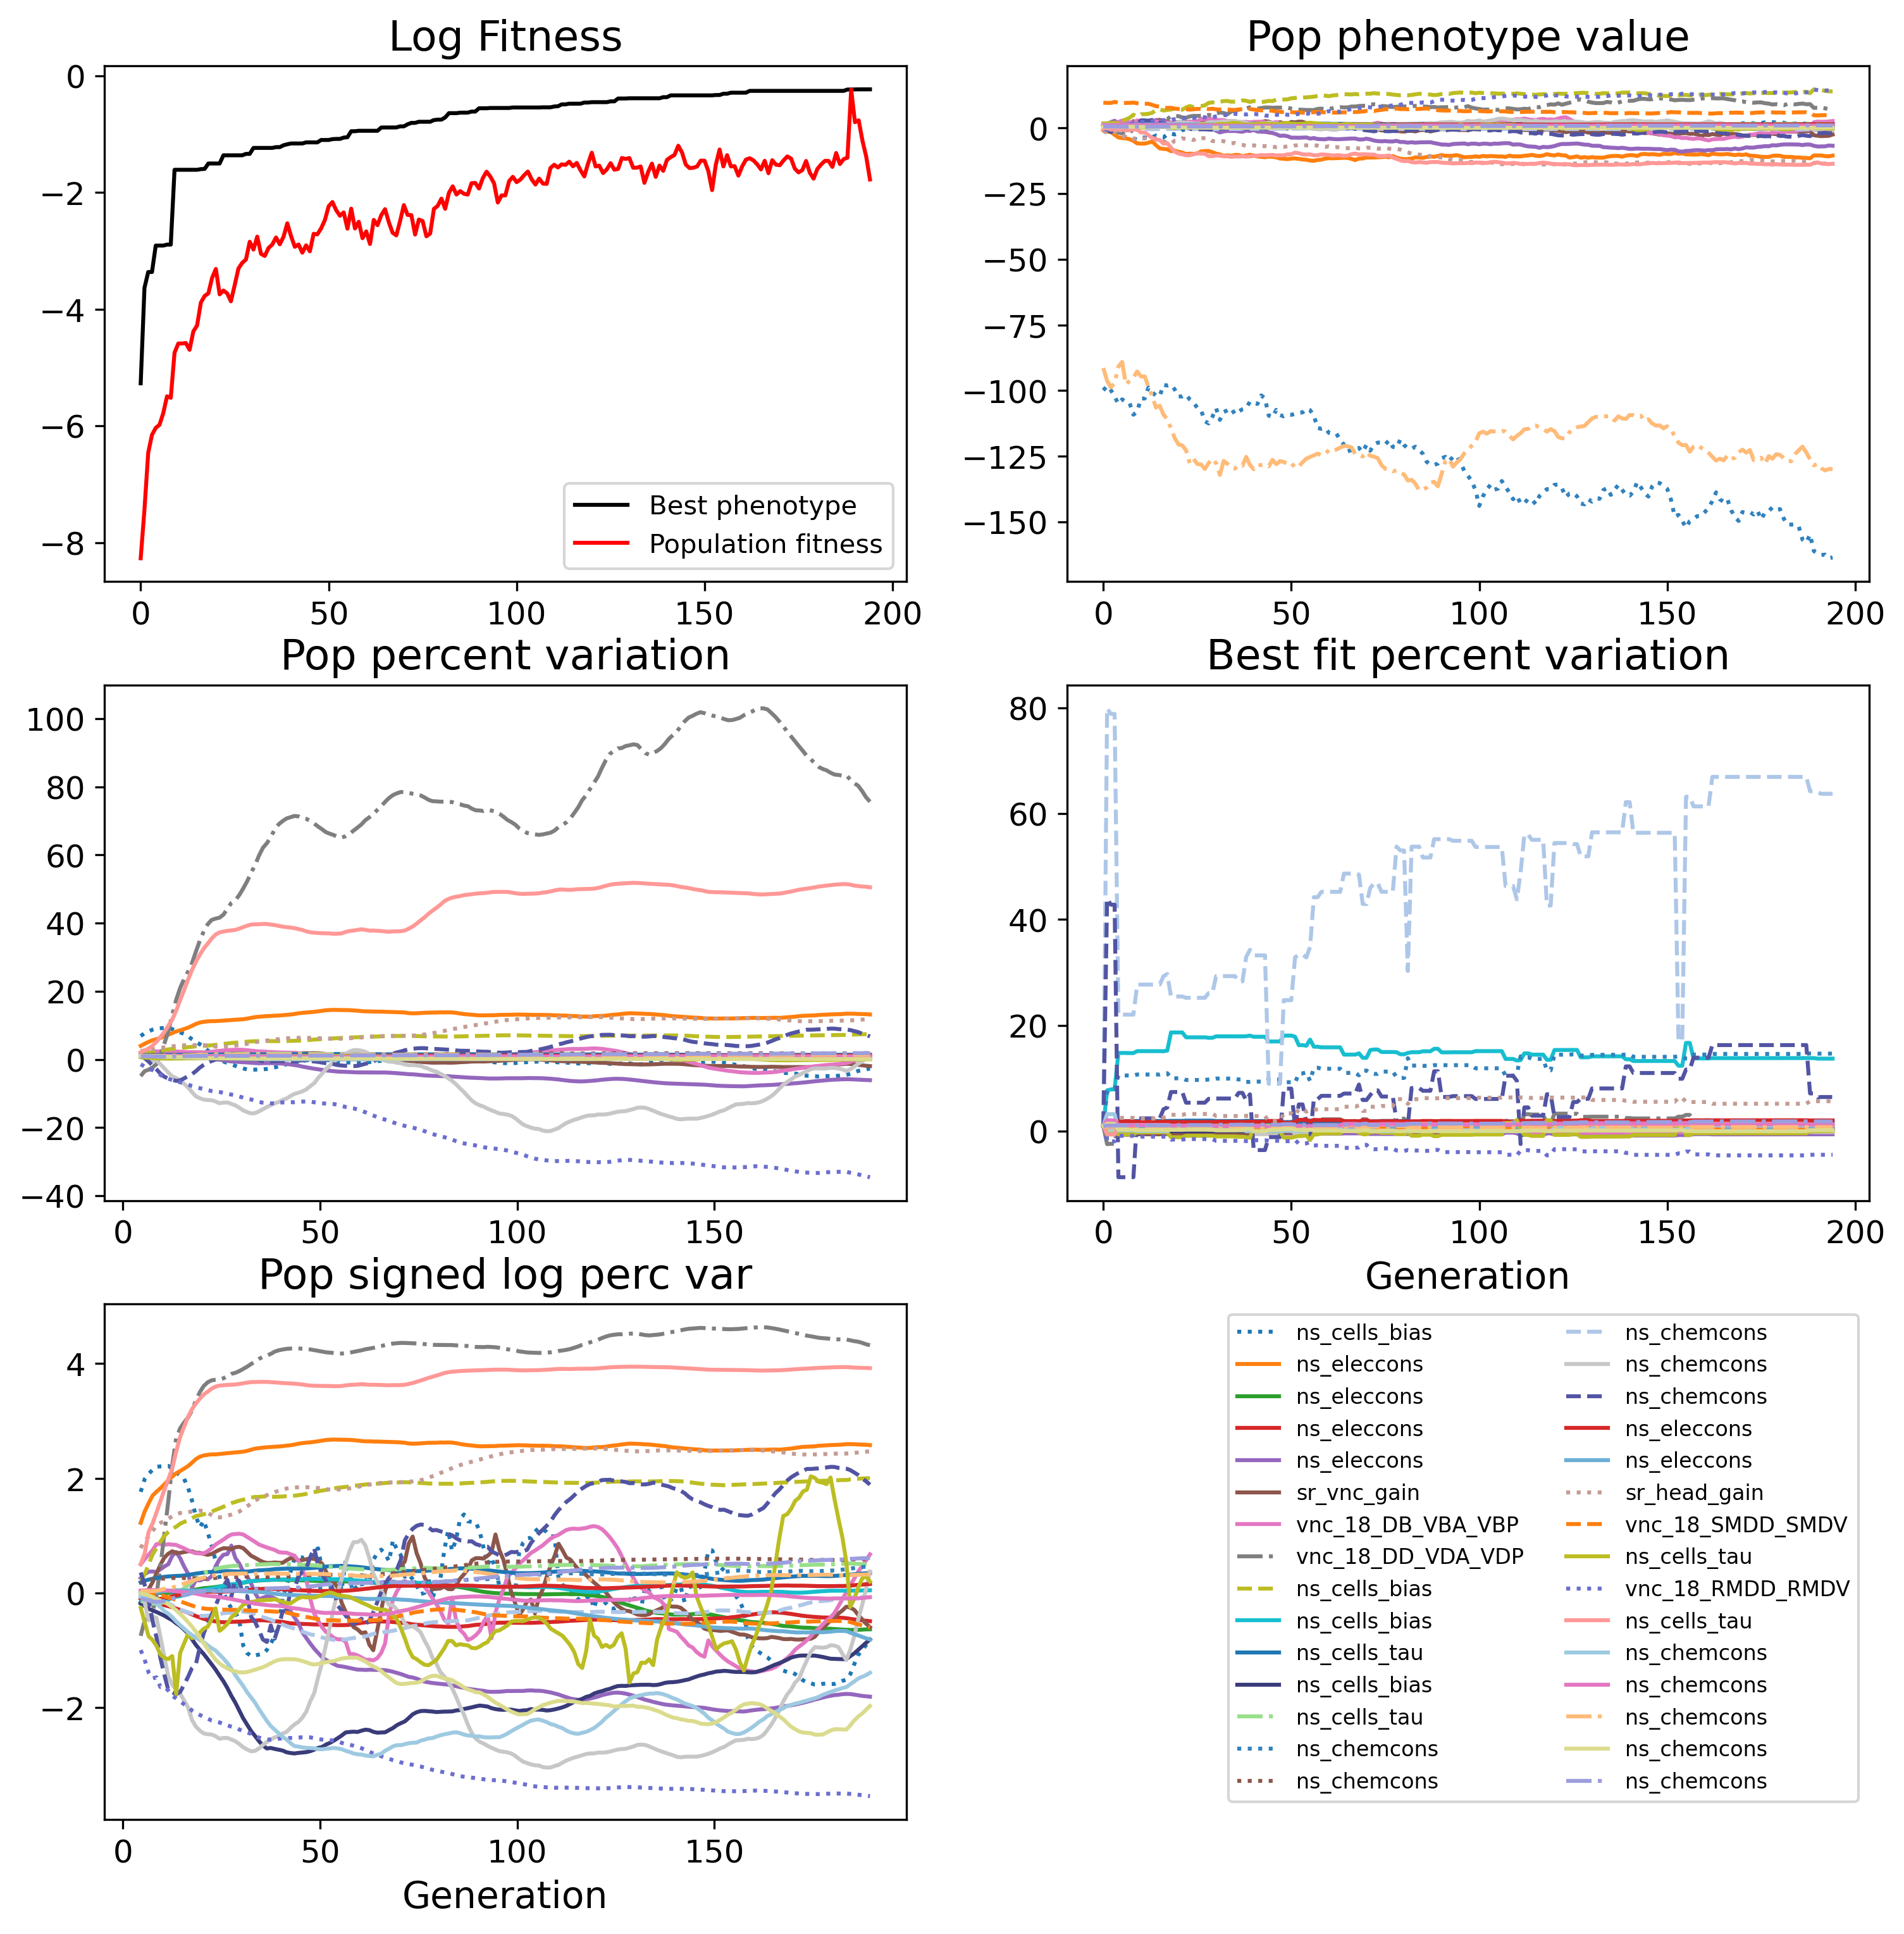

In [8]:
args['inputFolderName']=None
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=5 #run the optimization for ten more generations 
args['popSize']=20 #population size for optimization
args["doCPT"]=False
run(**args)
new_json_data = get_worm_json(outputFolderName)
Image(filename=outputFolderName + '/EvoHist.png')

In [9]:
with open(outputFolderName + '/fitness.dat') as f:
    lines = f.readlines()
print(''.join(lines[-20:]))

175.0 0.7721968913 0.1910316735 0.09025206049
176.0 0.7721968913 0.1983732874 0.08925659604
177.0 0.7721968913 0.2322568728 0.09706176101
178.0 0.7721968913 0.1899098001 0.08192311125
179.0 0.7721968913 0.1714120528 0.08265401252
180.0 0.7721968913 0.2025202607 0.08576220081
181.0 0.7721968913 0.2186193757 0.08507806098
182.0 0.7721968913 0.2325960988 0.09321619325
183.0 0.7721968913 0.2325960988 0.09321619325
184.0 0.7721968973 0.209871112 0.08023946681
185.0 0.7721968973 0.2661167143 0.09742796245
186.0 0.7721968973 0.2203478686 0.09655478645
187.0 0.7721968973 0.2397428535 0.1009723406
188.0 0.7903654022 0.2457370292 0.1033548627
189 0.7903654022 0.7903654022 0
190 0.7915886411 0.451556087 0.1440786763
191 0.7927009724 0.4659834787 0.1281864329
192 0.7927009724 0.3284939191 0.1249012654
193 0.7927009724 0.2503932009 0.1082852877
194 0.7927009724 0.1692069583 0.08449888363



In [10]:
print(json.dumps(new_json_data['Evolutionary Optimization Parameters']['PopulationSize'], indent=2))

{
  "value": 20
}


Directory 'notebooks/example_W2D18L_evo' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '30', '--max_generations', '5', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo', '--modelname', 'W2DSR', '-docpt', '0']
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
construct from best gene notebooks/example_W2D18L_evo/best.gen.dat with gene size 30
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json

Loading activity data from: notebooks/example_W2D18L_evo/act.dat
Loading curvature data from: notebooks/example_W2D18L_evo/curv.dat
Loading body position data from: notebooks/example_W2D18L_evo/body.dat
Saved plot image to: notebooks/example_W2D18L_evo/ExampleActivity.png
Saved plot image to: notebooks/example_W2D18L_evo/

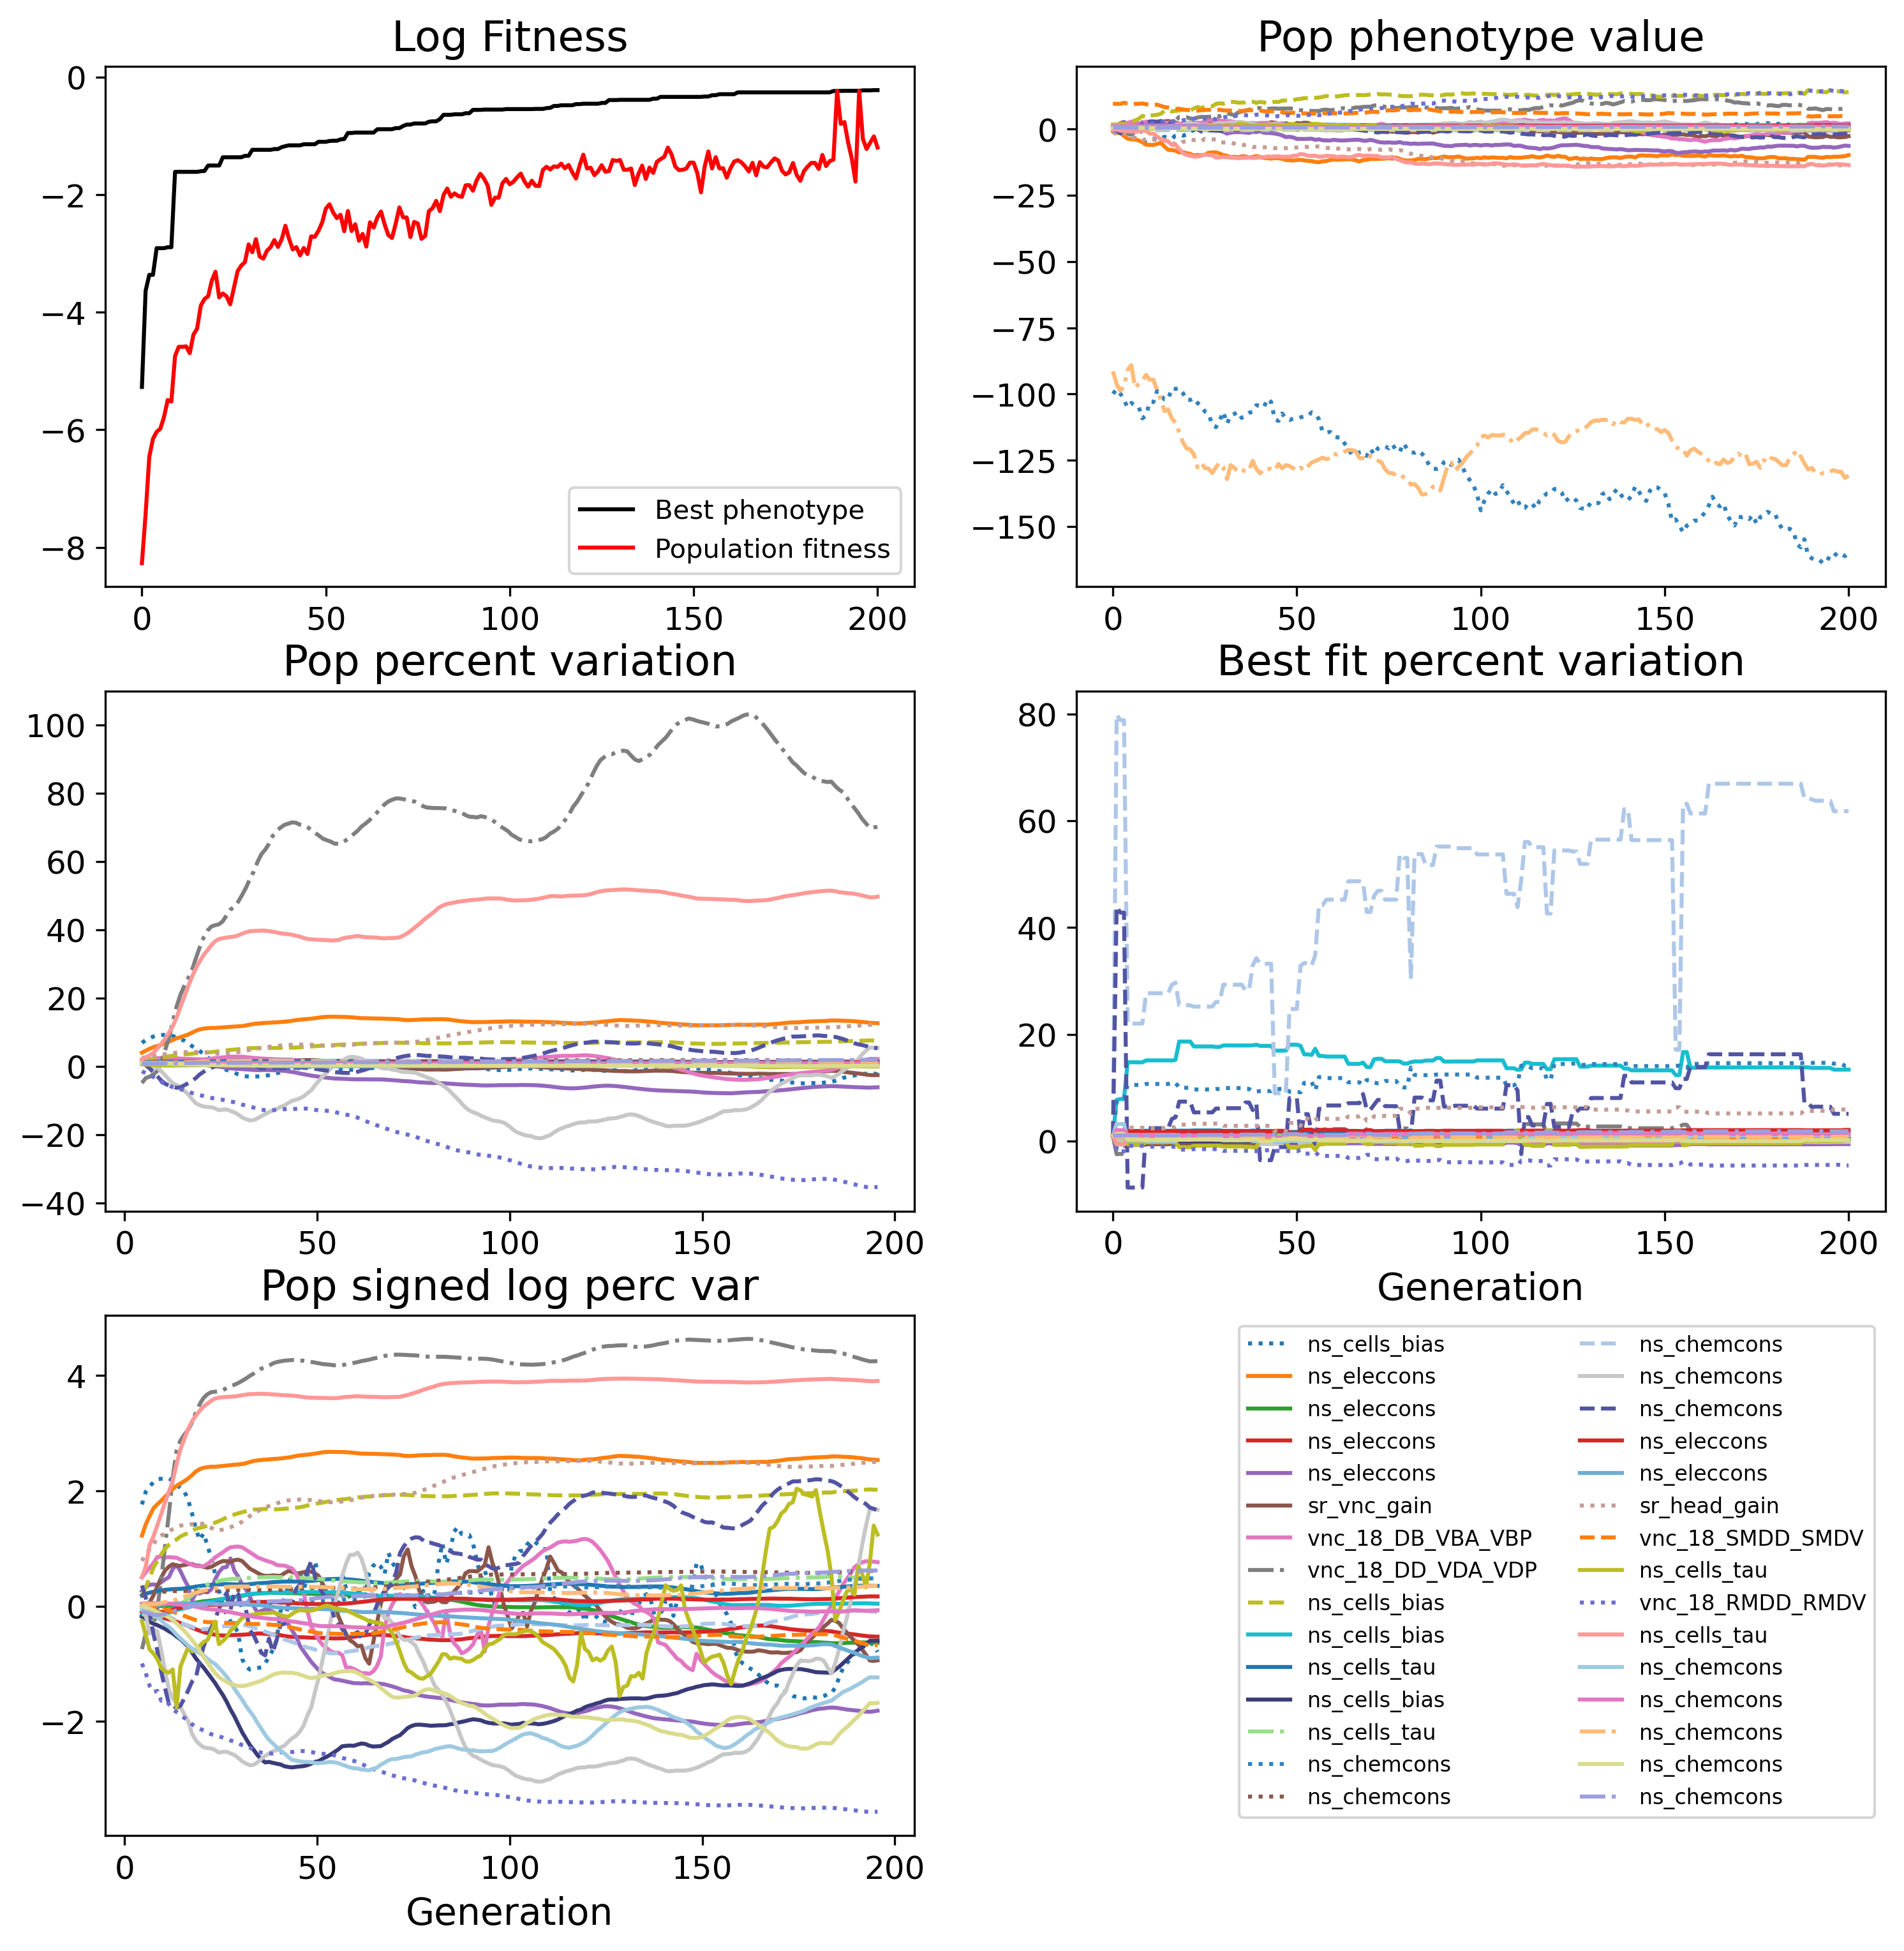

In [11]:
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=5 #run the optimization for ten more generations 
args['popSize']=30 #population size for optimization
args["doCPT"]=False
run(**args)
new_json_data = get_worm_json(outputFolderName)
Image(filename=outputFolderName + '/EvoHist.png')

In [12]:
with open(outputFolderName + '/fitness.dat') as f:
    lines = f.readlines()
print(''.join(lines[-20:]))

181.0 0.7721968913 0.2186193757 0.08507806098
182.0 0.7721968913 0.2325960988 0.09321619325
183.0 0.7721968913 0.2325960988 0.09321619325
184.0 0.7721968973 0.209871112 0.08023946681
185.0 0.7721968973 0.2661167143 0.09742796245
186.0 0.7721968973 0.2203478686 0.09655478645
187.0 0.7721968973 0.2397428535 0.1009723406
188.0 0.7903654022 0.2457370292 0.1033548627
189.0 0.7903654022 0.7903654022 0.0
190.0 0.7915886411 0.451556087 0.1440786763
191.0 0.7927009724 0.4659834787 0.1281864329
192.0 0.7927009724 0.3284939191 0.1249012654
193.0 0.7927009724 0.2503932009 0.1082852877
194.0 0.7927009724 0.1692069583 0.08449888363
195 0.7927009724 0.7927009724 0
196 0.7991506312 0.3507327141 0.1524631922
197 0.7991506312 0.2947379704 0.1368065418
198 0.7991506312 0.3283607177 0.1315352955
199 0.8020263046 0.3651595391 0.1412289476
200 0.8020263046 0.302186683 0.1313847106



In [13]:
print(json.dumps(new_json_data['Evolutionary Optimization Parameters']['PopulationSize'], indent=2))

{
  "value": 30
}


When doCPT is set to True again the evolution will resume from the last checkpoint file, which here has a population size of 30 according to the last evolutionary simulation: 

Directory 'notebooks/example_W2D18L_evo' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '40', '--max_generations', '5', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo', '--modelname', 'W2DSR', '-docpt', '1']
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_evo/search.cpt with size 30
setting  population size to cpt population size: 30
Resuming search
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json

Loading activity data from: notebooks/example_W2D18L_evo/act.dat
Loading curvature data from: notebooks/example_W2D18L_evo/curv.dat
Loading body position data from: notebooks/example_W2D18L_evo/body.dat
Saved plot image to: notebooks/example_W2D18L_evo/ExampleActivity

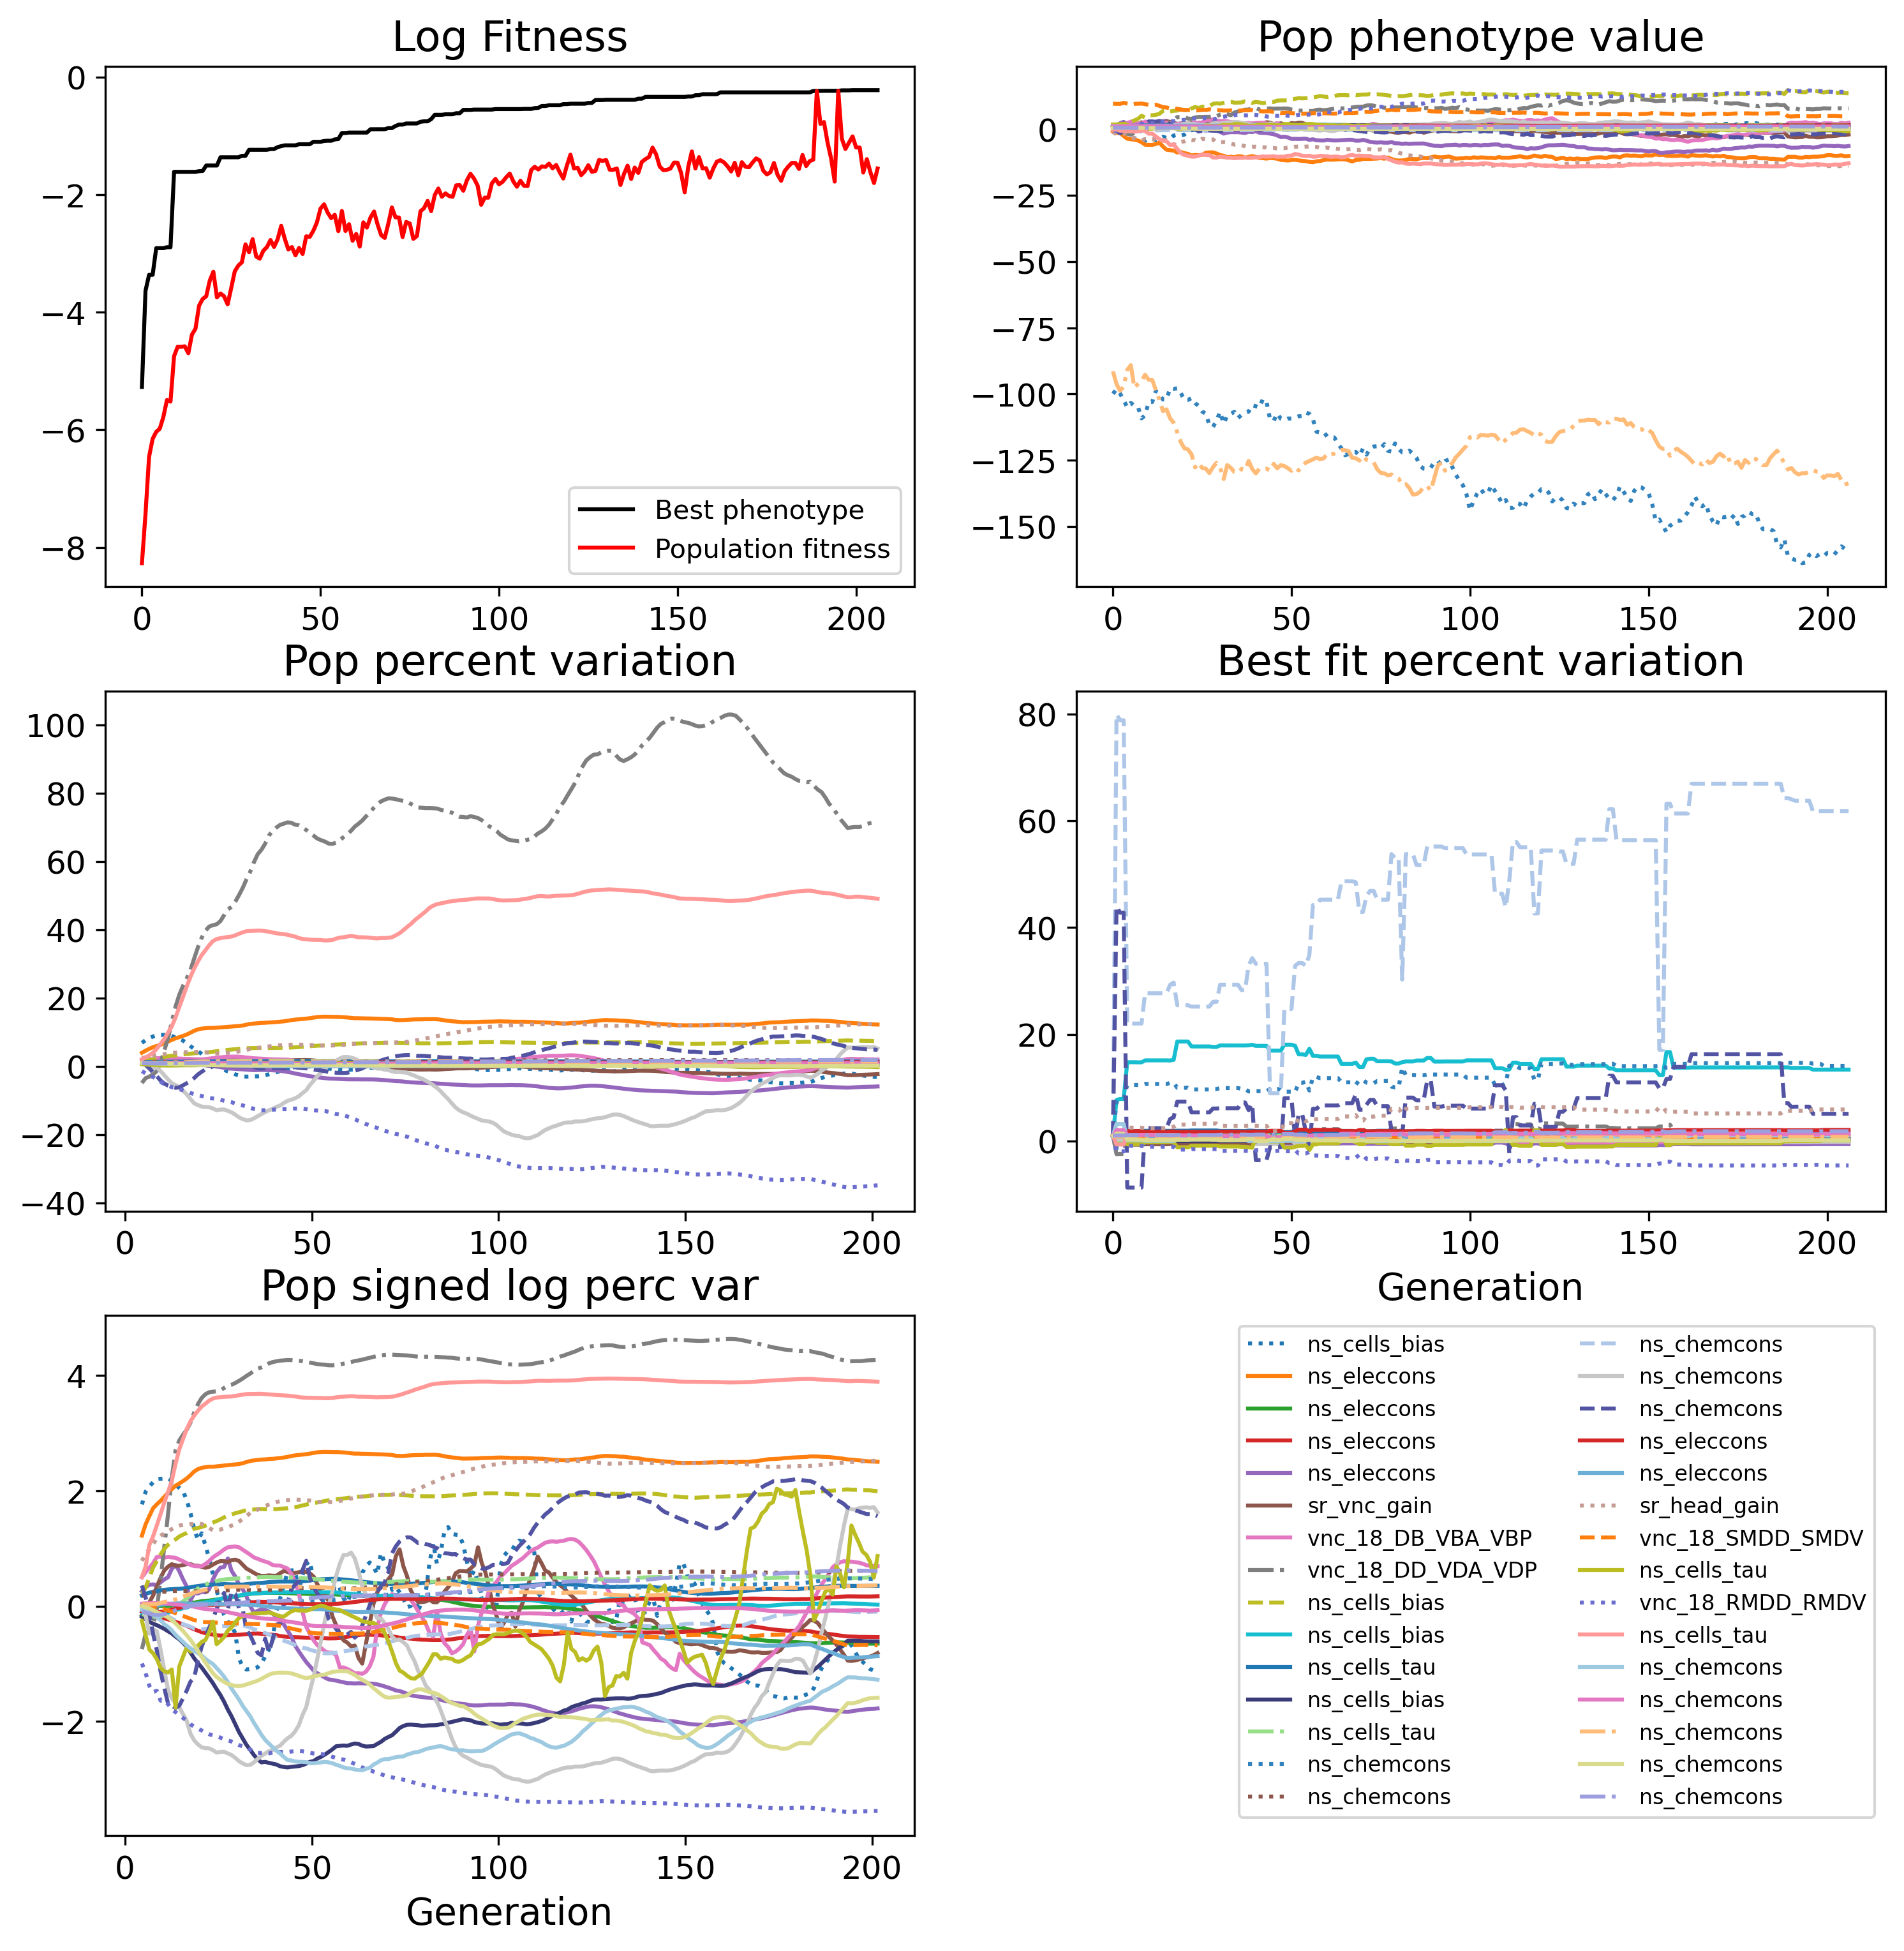

In [14]:
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=5 #run the optimization for ten more generations 
args['popSize']=40 #population size for optimization
args["doCPT"]=True
run(**args)
new_json_data = get_worm_json(outputFolderName)
Image(filename=outputFolderName + '/EvoHist.png')

In [15]:
with open(outputFolderName + '/fitness.dat') as f:
    lines = f.readlines()
print(''.join(lines[-20:]))

187.0 0.7721968973 0.2397428535 0.1009723406
188.0 0.7903654022 0.2457370292 0.1033548627
189.0 0.7903654022 0.7903654022 0.0
190.0 0.7915886411 0.451556087 0.1440786763
191.0 0.7927009724 0.4659834787 0.1281864329
192.0 0.7927009724 0.3284939191 0.1249012654
193.0 0.7927009724 0.2503932009 0.1082852877
194.0 0.7927009724 0.1692069583 0.08449888363
195.0 0.7927009724 0.7927009724 0.0
196.0 0.7991506312 0.3507327141 0.1524631922
197.0 0.7991506312 0.2947379704 0.1368065418
198.0 0.7991506312 0.3283607177 0.1315352955
199.0 0.8020263046 0.3651595391 0.1412289476
200.0 0.8020263046 0.302186683 0.1313847106
201 0.8020263046 0.302186683 0.1313847106
202 0.8020263046 0.1972184406 0.1088720983
203 0.8020263046 0.2479557437 0.1178560906
204 0.8020263046 0.1983450589 0.09013302294
205 0.8020263046 0.1651276043 0.08638819574
206 0.8020263046 0.2111519083 0.1011025148



In [16]:
print(json.dumps(new_json_data['Evolutionary Optimization Parameters']['PopulationSize'], indent=2))

{
  "value": 30
}


The optimizable parameters are indicated in the 'evolvable_ranges' object of the JSON file. Each entry has an 'evotag' which indicates which worm parameters it represents (see below). The parameter can vary within the prescribed upper and lower limits. Each entry also has a name which is not unique indicating the type of parameter it is. There may be several different optimizable cell bias parameters, for example. A parameter can be set to be inactive to remove it from the optimization.  

In [17]:
print(json.dumps(new_json_data['evolvable_ranges'], indent=2))

{
  "evotag_1": {
    "active": true,
    "lower_limit": -15.0,
    "name": "ns_cells_bias",
    "upper_limit": 15.0
  },
  "evotag_10": {
    "active": true,
    "lower_limit": 0.0,
    "name": "ns_eleccons",
    "upper_limit": 2.0
  },
  "evotag_11": {
    "active": true,
    "lower_limit": 0.0,
    "name": "ns_eleccons",
    "upper_limit": 2.0
  },
  "evotag_12": {
    "active": true,
    "lower_limit": 0.0,
    "name": "ns_eleccons",
    "upper_limit": 2.0
  },
  "evotag_13": {
    "active": true,
    "lower_limit": 0.0,
    "name": "ns_eleccons",
    "upper_limit": 2.0
  },
  "evotag_14": {
    "active": true,
    "lower_limit": -200.0,
    "name": "sr_vnc_gain",
    "upper_limit": 0.0
  },
  "evotag_15": {
    "active": true,
    "lower_limit": 0.0,
    "name": "vnc_18_DB_VBA_VBP",
    "upper_limit": 1.0
  },
  "evotag_16": {
    "active": true,
    "lower_limit": -1.0,
    "name": "vnc_18_DD_VDA_VDP",
    "upper_limit": 0.0
  },
  "evotag_17": {
    "active": true,
    "lower_li

The 'evotags' can be found in the json configuration file next to the value they correspond to. For example cells VDP_0 and VDP_1 both contain the 'evotag_2' in their bias field, which means both these biases will be set to the same value and this value will be optimized. Their 'tau' fields are also the same and optimized. The 'values' set in the json file are those taken from the best fit worm.

In [18]:
print('VDP_0: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_0'], indent=2))
print('VDP_1: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_1'], indent=2))

VDP_0: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.123621452393285
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.1527777777777778
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 0.7166647891006072
  }
}
VDP_1: {
  "bias": {
    "evotag": "evotag_2",
    "value": -10.123621452393285
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.3194444444444444
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 0.7166647891006072
  }
}


After an evolution these values may be changed if the best fit worm is changed:

Directory 'notebooks/example_W2D18L_evo' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '40', '--max_generations', '10', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo', '--modelname', 'W2DSR', '-docpt', '1']
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
construct from CPT notebooks/example_W2D18L_evo/search.cpt with size 30
setting  population size to cpt population size: 30
Resuming search
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json

Loading activity data from: notebooks/example_W2D18L_evo/act.dat
Loading curvature data from: notebooks/example_W2D18L_evo/curv.dat
Loading body position data from: notebooks/example_W2D18L_evo/body.dat
Saved plot image to: notebooks/example_W2D18L_evo/ExampleActivit

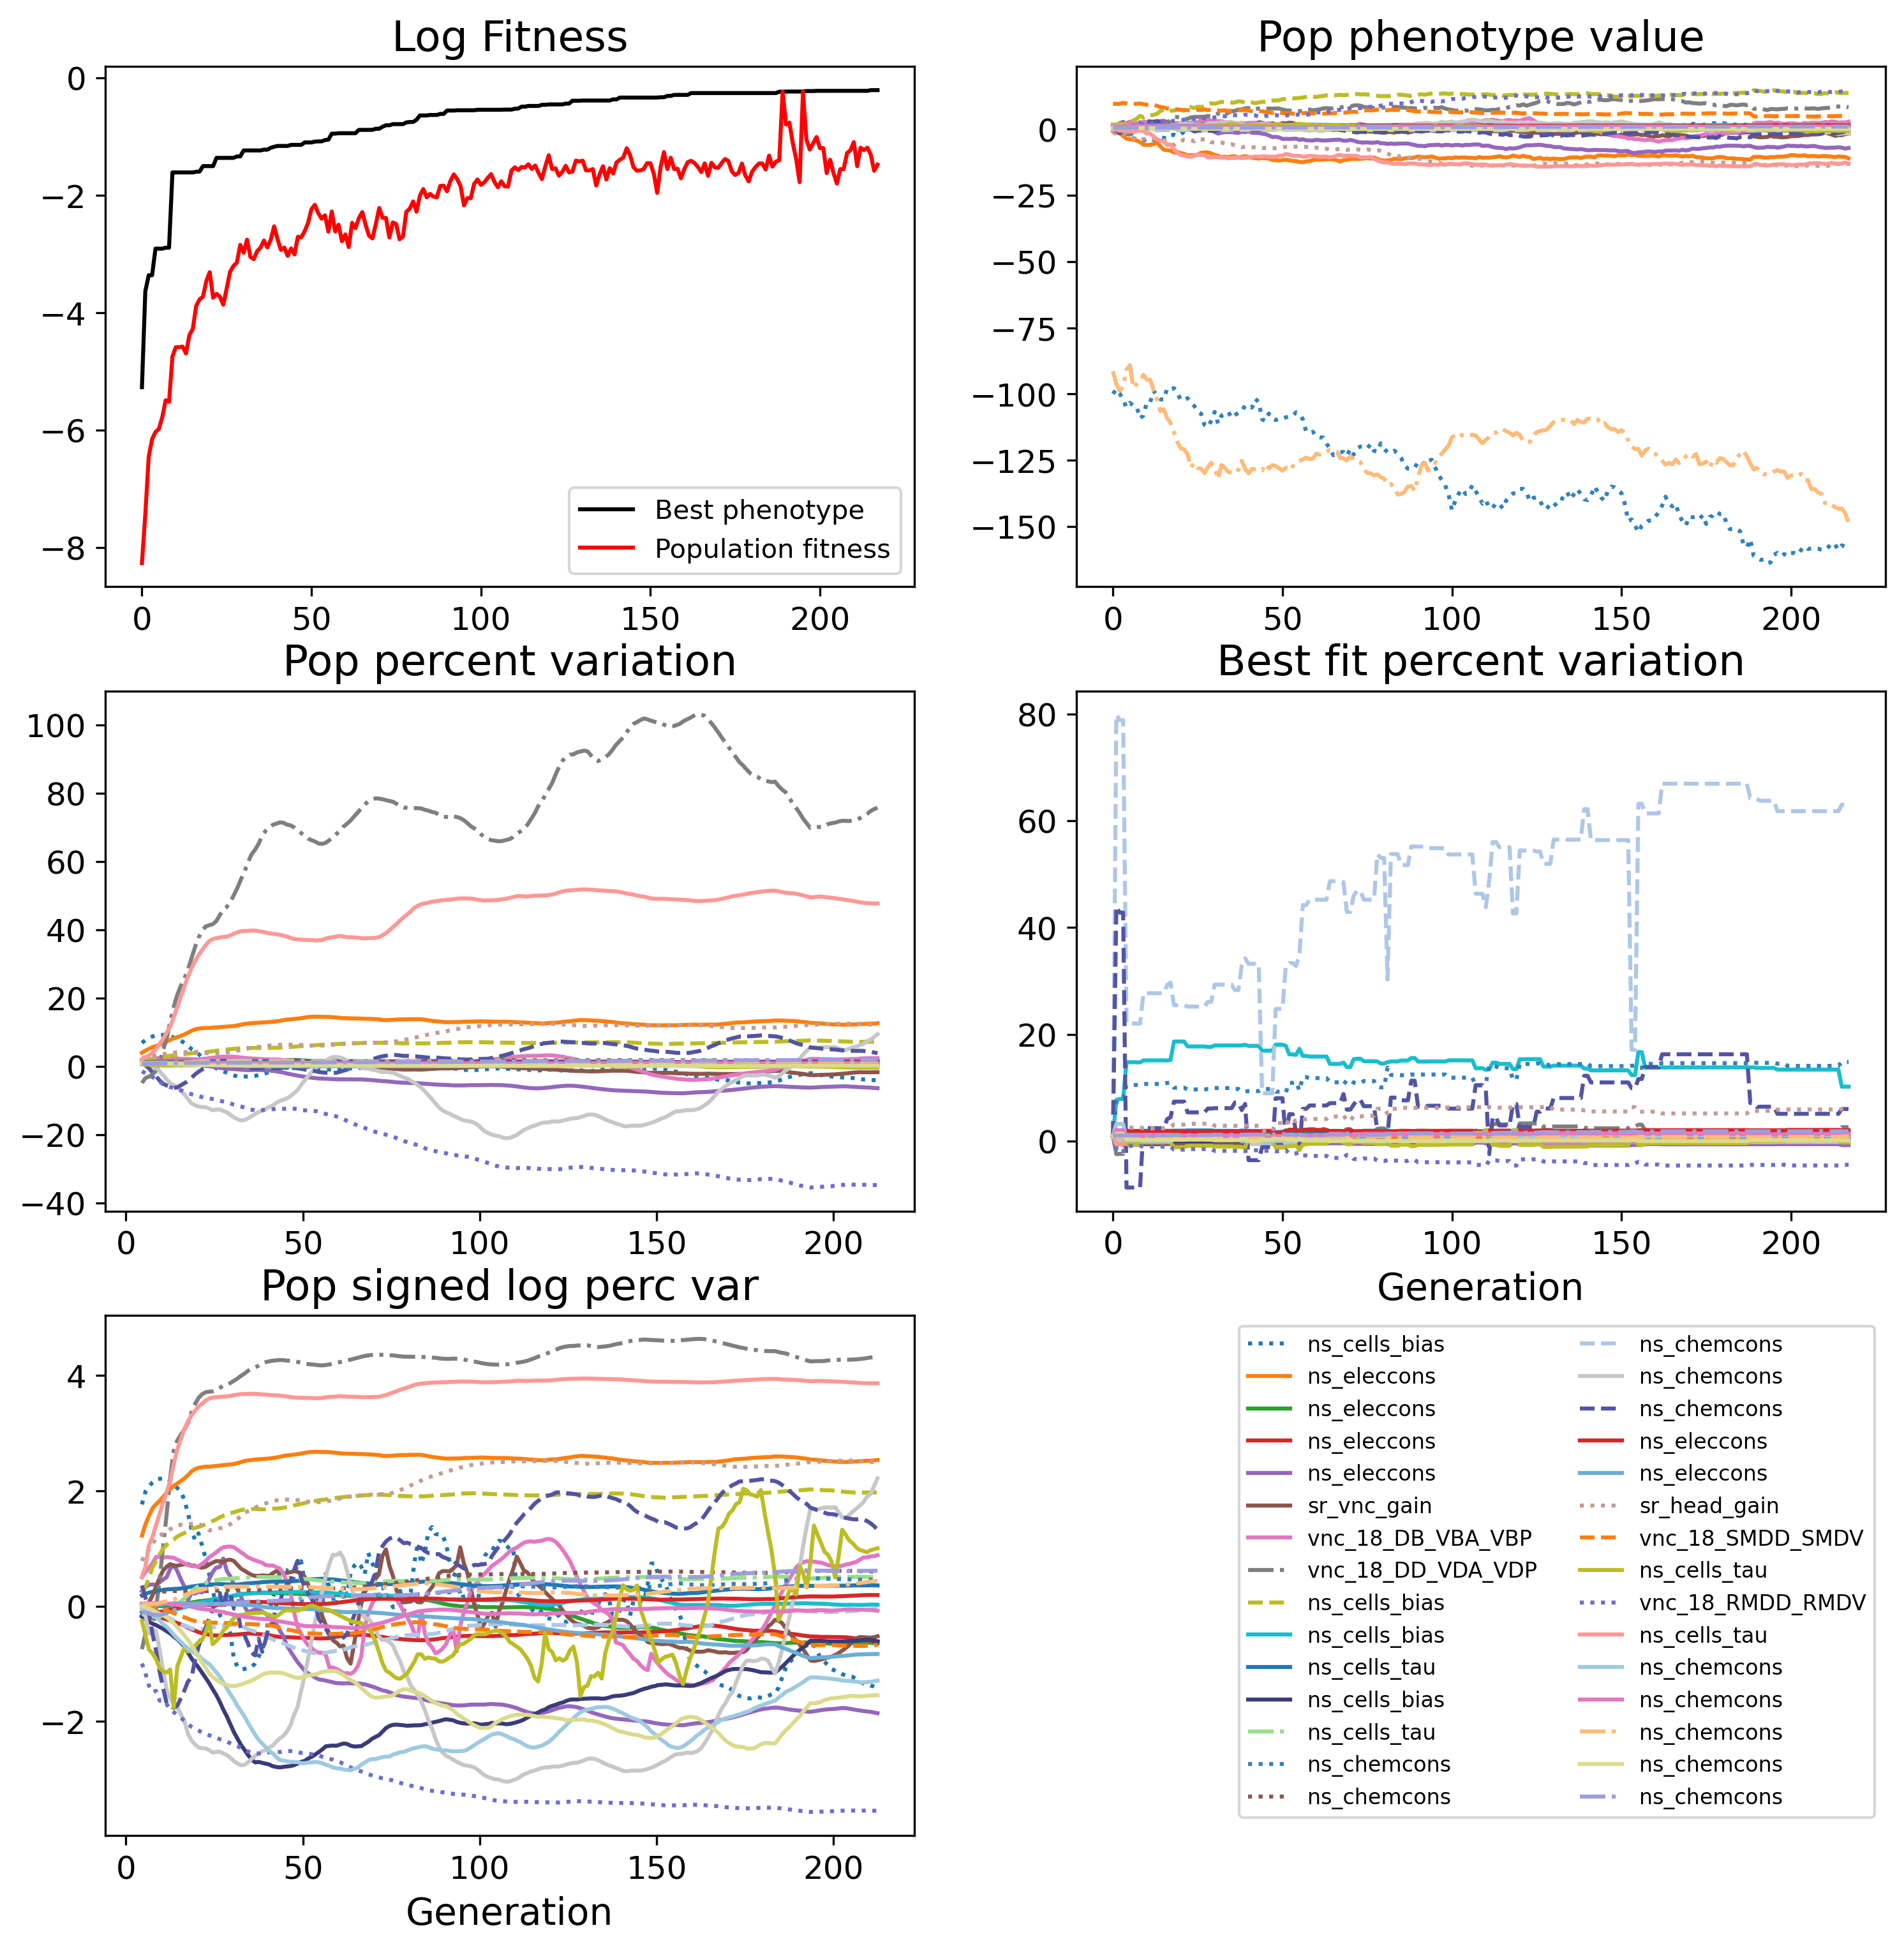

In [19]:
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=10 #run the optimization for ten more generations 
args["doCPT"]=True
run(**args)
new_json_data = get_worm_json(outputFolderName)
Image(filename=outputFolderName + '/EvoHist.png')

In [20]:
with open(outputFolderName + '/fitness.dat') as f:
    lines = f.readlines()
print(''.join(lines[-20:]))

198.0 0.7991506312 0.3283607177 0.1315352955
199.0 0.8020263046 0.3651595391 0.1412289476
200.0 0.8020263046 0.302186683 0.1313847106
201.0 0.8020263046 0.302186683 0.1313847106
202.0 0.8020263046 0.1972184406 0.1088720983
203.0 0.8020263046 0.2479557437 0.1178560906
204.0 0.8020263046 0.1983450589 0.09013302294
205.0 0.8020263046 0.1651276043 0.08638819574
206.0 0.8020263046 0.2111519083 0.1011025148
207 0.8020263046 0.2111519083 0.1011025148
208 0.8020263046 0.2779607168 0.1003455811
209 0.8020263046 0.2911389831 0.1074032593
210 0.8020263046 0.3347880465 0.1142129456
211 0.8020263046 0.2223728196 0.09833921861
212 0.8020263046 0.3043266498 0.1188440801
213 0.8020263046 0.291982502 0.1267970319
214 0.8020263046 0.3047757098 0.1297297894
215 0.8118079769 0.2703445993 0.1143855619
216 0.8118079769 0.2052878681 0.09613245012
217 0.8118079769 0.2281448627 0.08421761488



These parameters have different values from before the latest optimization run:

In [21]:
print('VDP_0: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_0'], indent=2))
print('VDP_1: ' + json.dumps(new_json_data['nervous_system']['cells']['VDP_1'], indent=2))

VDP_0: {
  "bias": {
    "evotag": "evotag_2",
    "value": -12.700291336340177
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.1527777777777778
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 0.5602968615835284
  }
}
VDP_1: {
  "bias": {
    "evotag": "evotag_2",
    "value": -12.700291336340177
  },
  "cell_class": {
    "value": "vnc"
  },
  "gain": {
    "value": 1.0
  },
  "state": {
    "value": 0.3194444444444444
  },
  "tau": {
    "evotag": "evotag_4",
    "value": 0.5602968615835284
  }
}


An optimizable parameter can be turned off:

In [22]:
print(json.dumps(new_json_data['evolvable_ranges']['evotag_2'], indent=2))
new_json_data['evolvable_ranges']['evotag_2']["active"] = False
print(json.dumps(new_json_data['evolvable_ranges']['evotag_2'], indent=2))

{
  "active": true,
  "lower_limit": -15.0,
  "name": "ns_cells_bias",
  "upper_limit": 15.0
}
{
  "active": false,
  "lower_limit": -15.0,
  "name": "ns_cells_bias",
  "upper_limit": 15.0
}


Make sure to save the modified json before running the optimization: 

Directory 'notebooks/example_W2D18L_evo' already exists and all the contents will be overwritten.
Parameter not found in worm_data.json
['Worm2D/main_osc', '--random_initial_state', '0', '--do_test_run', '1', '--population_size', '40', '--max_generations', '10', '--doevol', '1', '--folder', 'notebooks/example_W2D18L_evo', '--modelname', 'W2DSR', '-docpt', '0']
jsonfile notebooks/example_W2D18L_evo/worm_data_worm.json
construct from best gene notebooks/example_W2D18L_evo/best.gen.dat with gene size 29
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json
jsonfile notebooks/example_W2D18L_evo/worm_data_evo.json

Loading activity data from: notebooks/example_W2D18L_evo/act.dat
Loading curvature data from: notebooks/example_W2D18L_evo/curv.dat
Loading body position data from: notebooks/example_W2D18L_evo/body.dat
Saved plot image to: notebooks/example_W2D18L_evo/ExampleActivity.png


IndexError: boolean index did not match indexed array along dimension 0; dimension is 240 but corresponding boolean dimension is 22

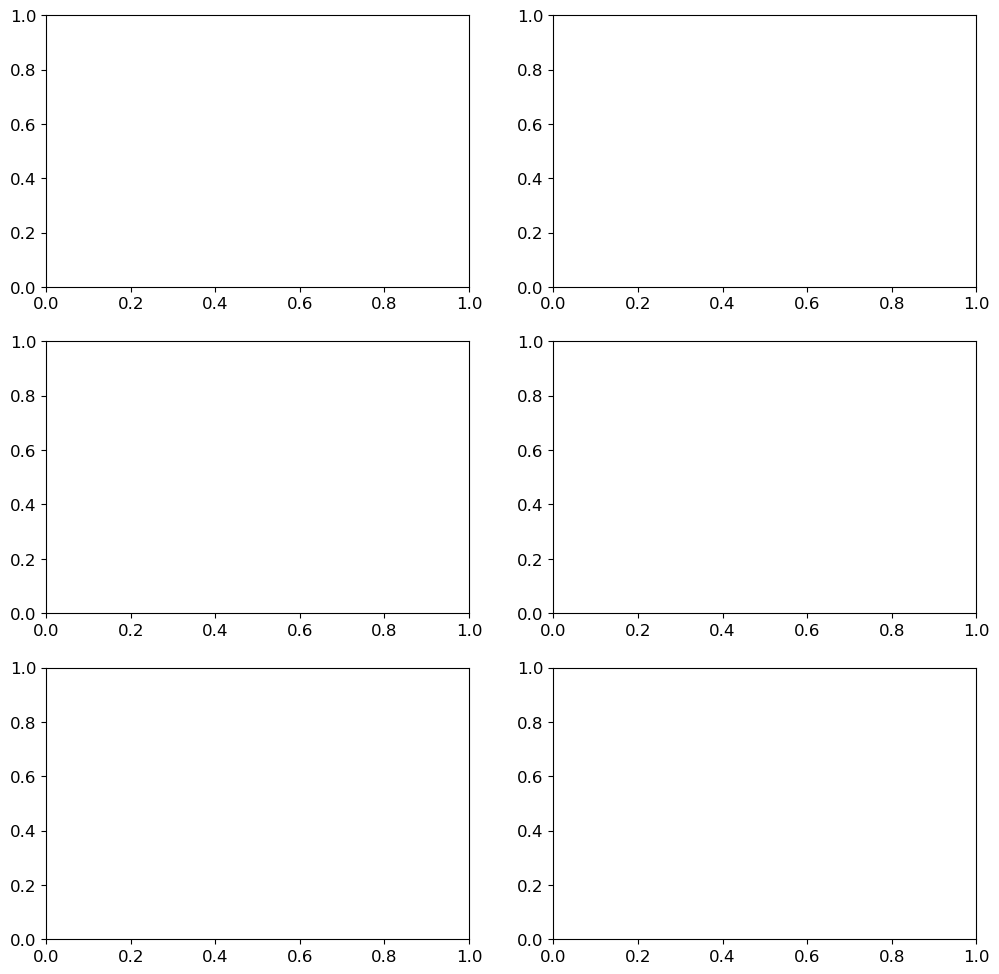

In [24]:
write_worm_json(outputFolderName, new_json_data)
args['doEvol']=True #perform the optimization before running the simulation
args['maxGens']=10 #run the optimization for ten more generations 
args["doCPT"]=False
run(**args)
new_json_data = get_worm_json(outputFolderName)
Image(filename=outputFolderName + '/EvoHist.png')

Some parameters may have an 'mfunc' field. This is a function which can be called on a value when it is set by the optimization or at other time (see below). 